In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt

from sklearn import datasets
from sklearn.cluster import KMeans

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#import du fichier avec les données complètes (pays+variables)
# Ayant trouvé l'Inde comme un outlier (forme tout seul un cluster), j'ai opté à le supprimer
# et à recharger les données sans Inde et à relancer le Kmeans pour voir le nouveau clustering

Donnees_sans_Inde_153 = pd.read_csv('/content/drive/MyDrive/Colab Notebooks/Donnees_sans_Inde_153.csv',decimal=".", index_col="Zone")
Donnees_sans_Inde_153.head()

,Unnamed: 0,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
Zone,,,,,,,,,,,
Afghanistan,0,5.0,254.0,26.0,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00
Albania,1,85.0,438.0,38.0,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06
Algeria,2,22.0,4858.0,2.0,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01
Angola,3,35.0,5873.0,277.0,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00
Argentina,4,182.0,16332.0,-199.0,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43


In [ ]:
# supprimer les colonnes  inutiles
Donnees_sans_Inde_153 = Donnees_sans_Inde_153.drop('Unnamed: 0', axis=1)
Donnees_sans_Inde_153.tail()

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
Zone,,,,,,,,,,
Vanuatu,40.0,1.0,1.0,58.23,30.84,16440.020,0.93,3.97,-0.12,3.44
Venezuela (Bolivarian Republic of),71.0,1020.0,25.0,19.41,1079.05,7736.347,-1.19,3.69,-2.03,0.01
Viet Nam,48.0,8824.0,290.0,19.57,11703.14,9869.467,-0.04,7.09,-0.38,1.41
Zambia,11.0,551.0,11.0,66.59,3653.36,7221.197,0.20,4.04,-0.50,0.01
Zimbabwe,16.0,44.0,3.0,21.52,3041.81,7759.680,-0.93,2.03,-1.34,0.00


In [ ]:
#Enregistrement des pays dans une varibale
pays = Donnees_sans_Inde_153.index
pays

Index(['Afghanistan', 'Albania', 'Algeria', 'Angola', 'Argentina', 'Armenia',
       'Australia', 'Austria', 'Azerbaijan', 'Bahamas',
       ...
       'United Kingdom of Great Britain and Northern Ireland',
       'United Republic of Tanzania', 'United States of America', 'Uruguay',
       'Uzbekistan', 'Vanuatu', 'Venezuela (Bolivarian Republic of)',
       'Viet Nam', 'Zambia', 'Zimbabwe'],
      dtype='object', name='Zone', length=152)

In [ ]:
cols=["Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour)","Quantité Aliments_disponible Poules(Milliers tonnes)","Export_Utile(Milliers tonnes)","Taux de croissance_population [%]","Emploi dans la production_vegetale_animale (1000No)",
     "Distance_Economique Pays_France(Km)","Indice Stabilite Politique","Croissance du PIB % annuel","Qualité Reglementaire [-2,5..+2,5]","[%]surfaces agricoles biologiques/total des terres agricoles"]

In [ ]:
df_clustering = Donnees_sans_Inde_153[cols]
df_clustering.head()

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
Zone,,,,,,,,,,
Afghanistan,5.0,254.0,26.0,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00
Albania,85.0,438.0,38.0,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06
Algeria,22.0,4858.0,2.0,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01
Angola,35.0,5873.0,277.0,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00
Argentina,182.0,16332.0,-199.0,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43


In [ ]:
#Sépartion de nos données. D'un coté X la matrice des données :

X = Donnees_sans_Inde_153.values
X[:5]

array([[ 5.000000e+00,  2.540000e+02,  2.600000e+01,  7.888000e+01,
         1.185840e+03,  5.489888e+03, -2.480000e+00,  2.270000e+00,
        -1.270000e+00,  0.000000e+00],
       [ 8.500000e+01,  4.380000e+02,  3.800000e+01, -7.880000e+00,
         4.216400e+02,  1.461321e+03,  1.800000e-01,  3.960000e+00,
         1.700000e-01,  6.000000e-02],
       [ 2.200000e+01,  4.858000e+03,  2.000000e+00,  3.604000e+01,
         0.000000e+00,  1.158292e+03, -5.800000e-01,  3.300000e+00,
        -9.500000e-01,  1.000000e-02],
       [ 3.500000e+01,  5.873000e+03,  2.770000e+02,  8.792000e+01,
         5.998460e+03,  6.363600e+03, -3.400000e-01,  4.420000e+00,
        -7.600000e-01,  0.000000e+00],
       [ 1.820000e+02,  1.633200e+04, -1.990000e+02,  2.032000e+01,
         6.822000e+01,  1.092186e+04, -1.300000e-01, -1.720000e+00,
        -4.800000e-01,  3.430000e+00]])

In [ ]:
#Centrer et réduire les données
#Scaling (Mise à l'échelle)

from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
X_scaled = scaler.fit_transform(df_clustering)

In [ ]:
##On espère avoir une moyenne à 0 et un écart type à 1
pd.DataFrame(X_scaled).describe().round(2).iloc[1:3:, : ]

,0,1,2,3,4,5,6,7,8,9
mean,0.0,0.0,-0.0,-0.0,-0.0,-0.0,0.0,0.0,0.0,-0.0
std,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0,1.0


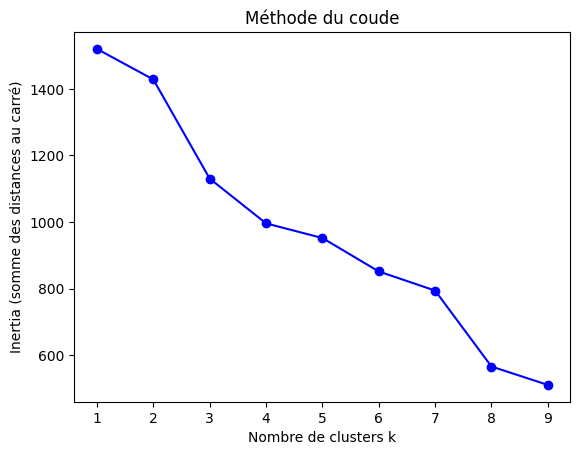

In [ ]:
#Utiliser la méthode du coude (elbow method) pour choisir k

inertia = []
K_range = range(1, 10)
for k in K_range:
  # On instancie un k-means pour k clusters
    kmeans = KMeans(n_clusters=k, random_state=42)
    # On entraine
    kmeans.fit(X_scaled)
    # On enregistre l'inertie obtenue :
    inertia.append(kmeans.inertia_)

plt.plot(K_range, inertia, 'bo-')
plt.xlabel('Nombre de clusters k')
plt.ylabel('Inertia (somme des distances au carré)')
plt.title('Méthode du coude')

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Clustering_Kmeans_Inde_153.png", dpi=300, bbox_inches="tight")

plt.show()

In [ ]:
#:Appliquer Kmeans

k =4 # choisi après la méthode du coude
kmeans = KMeans(n_clusters=k, random_state=42)
clusters = kmeans.fit_predict(X_scaled)

# Ajouter les labels au DataFrame
df_clustering['cluster'] = clusters
df_clustering.head()

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles,cluster
Zone,,,,,,,,,,,
Afghanistan,5.0,254.0,26.0,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00,2
Albania,85.0,438.0,38.0,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06,1
Algeria,22.0,4858.0,2.0,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01,2
Angola,35.0,5873.0,277.0,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00,2
Argentina,182.0,16332.0,-199.0,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43,3


In [ ]:
df_clustering.shape

(152, 11)

In [ ]:
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
#Clustering
#Nous allons calculer les distances en spécifiant la méthode à utiliser:

Z = linkage(X_scaled, method="ward")
Z[:10]

array([[ 11.        ,  53.        ,   0.32973708,   2.        ],
       [ 91.        , 101.        ,   0.33506841,   2.        ],
       [ 43.        ,  77.        ,   0.35314957,   2.        ],
       [131.        , 132.        ,   0.52965971,   2.        ],
       [ 55.        ,  87.        ,   0.53770171,   2.        ],
       [ 48.        ,  78.        ,   0.62198052,   2.        ],
       [ 15.        , 120.        ,   0.62844964,   2.        ],
       [122.        , 156.        ,   0.65660793,   3.        ],
       [ 54.        ,  58.        ,   0.65726788,   2.        ],
       [  1.        ,  20.        ,   0.6670586 ,   2.        ]])

In [ ]:
#Clusters
k=4


clusters = fcluster(Z, k, criterion='maxclust')
clusters


array([1, 1, 1, 1, 4, 1, 4, 3, 1, 4, 1, 4, 1, 3, 4, 1, 4, 1, 4, 2, 1, 1,
       1, 1, 4, 1, 4, 2, 4, 1, 4, 3, 1, 4, 3, 1, 3, 4, 4, 4, 1, 4, 3, 1,
       1, 4, 3, 3, 1, 1, 3, 1, 3, 4, 4, 1, 1, 1, 4, 3, 3, 1, 1, 1, 3, 4,
       3, 4, 4, 1, 1, 4, 4, 1, 1, 3, 1, 1, 1, 3, 3, 1, 1, 4, 1, 1, 1, 1,
       4, 4, 1, 1, 1, 1, 1, 1, 1, 4, 4, 1, 1, 1, 3, 4, 1, 4, 1, 4, 1, 3,
       3, 4, 1, 3, 1, 1, 4, 4, 3, 4, 1, 1, 1, 1, 3, 4, 4, 3, 1, 1, 4, 3,
       3, 1, 1, 4, 1, 1, 1, 1, 1, 4, 3, 1, 2, 3, 1, 4, 1, 1, 1, 1],
      dtype=int32)

In [ ]:
df = pd.DataFrame({"pays" : pays,"cluster" : clusters})
df.head()

,pays,cluster
0,Afghanistan,1
1,Albania,1
2,Algeria,1
3,Angola,1
4,Argentina,4


In [ ]:
df.shape

(152, 2)

In [ ]:
#Affichade des   clusters

for i in range(1, 5) :
    # on fait une selection
    sub_df = df.loc[df.cluster == i]

    # le cluster en question
    print(f"cluster : {i}")

    # on extrait les pays de chaque ligne
    names_list = sub_df.pays.values



    ziped = zip(names_list)
    txt = [f"{n}" for n in ziped]

    # on transforme en str
    txt = " / ".join(txt)



    # on print
    print(txt)
    print("\n\n")




cluster : 1
('Afghanistan',) / ('Albania',) / ('Algeria',) / ('Angola',) / ('Armenia',) / ('Azerbaijan',) / ('Bangladesh',) / ('Belarus',) / ('Benin',) / ('Bosnia and Herzegovina',) / ('Bulgaria',) / ('Burkina Faso',) / ('Cambodia',) / ('Cameroon',) / ('Chad',) / ('Congo',) / ('Cuba',) / ("Côte d'Ivoire",) / ('Egypt',) / ('Eswatini',) / ('Ethiopia',) / ('Gambia',) / ('Georgia',) / ('Ghana',) / ('Guinea-Bissau',) / ('Guyana',) / ('Haiti',) / ('Indonesia',) / ('Iran (Islamic Republic of)',) / ('Iraq',) / ('Kazakhstan',) / ('Kenya',) / ('Kyrgyzstan',) / ("Lao People's Democratic Republic",) / ('Lebanon',) / ('Lesotho',) / ('Liberia',) / ('Madagascar',) / ('Malawi',) / ('Maldives',) / ('Mali',) / ('Malta',) / ('Mauritania',) / ('Mongolia',) / ('Montenegro',) / ('Morocco',) / ('Mozambique',) / ('Myanmar',) / ('Namibia',) / ('Nepal',) / ('Niger',) / ('Nigeria',) / ('North Macedonia',) / ('Pakistan',) / ('Paraguay',) / ('Philippines',) / ('Republic of Moldova',) / ('Russian Federation',) / ('

In [ ]:
#Le dataframe d’analyse = dataframe initial + colonne “Cluster”


# Mise à jour du DataFrame
df_clustering['cluster'] = clusters

df_analyse = df_clustering
df_analyse.head()





,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles,cluster
Zone,,,,,,,,,,,
Afghanistan,5.0,254.0,26.0,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00,1
Albania,85.0,438.0,38.0,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06,1
Algeria,22.0,4858.0,2.0,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01,1
Angola,35.0,5873.0,277.0,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00,1
Argentina,182.0,16332.0,-199.0,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43,4


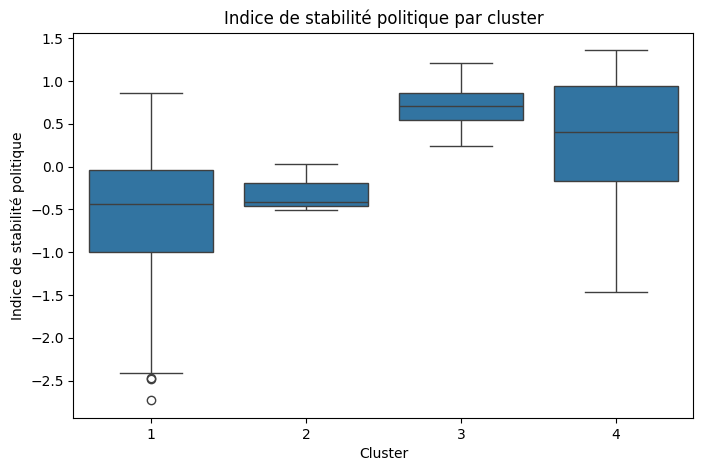

In [ ]:
#Boxplot de l'indice de stabilité politique par rapport aux clusters

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df_analyse['cluster'],
    y=df_analyse['Indice Stabilite Politique']
)


plt.title("Indice de stabilité politique par cluster")
plt.xlabel("Cluster")
plt.ylabel("Indice de stabilité politique")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/BoxplotPolitique_cluter.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
#Barplot (moyenne) Quantité d’aliments disponibles pour les poules par rapport au clusters
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# Calcul de la moyenne par cluster
df_mean = (df_analyse.groupby('cluster', as_index=False)['Quantité Aliments_disponible Poules(Milliers tonnes)'].mean()
)


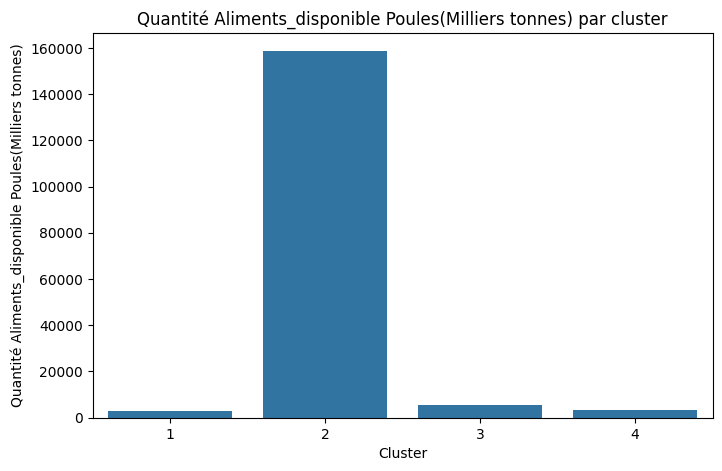

In [ ]:
plt.figure(figsize=(8,5))

sns.barplot(
    x='cluster',
    y='Quantité Aliments_disponible Poules(Milliers tonnes)',
    data=df_mean
)

plt.title("Quantité Aliments_disponible Poules(Milliers tonnes) par cluster")
plt.xlabel("Cluster")
plt.ylabel("Quantité Aliments_disponible Poules(Milliers tonnes)")
#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/BarplotQuantiteAliment_cluter.png", dpi=300, bbox_inches="tight")
plt.show()


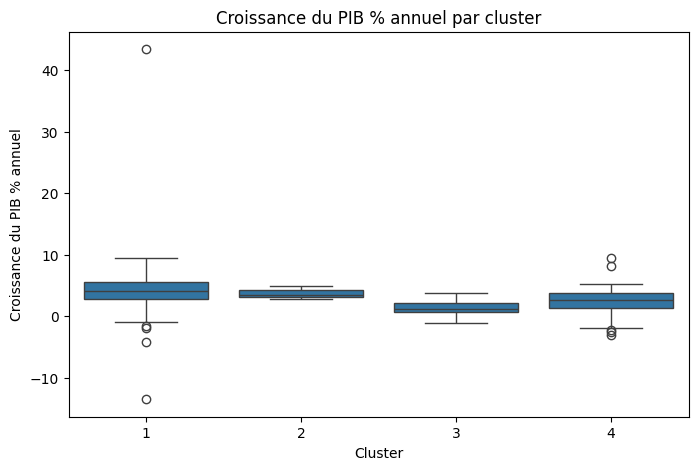

In [ ]:
#Boxplot de l'Croissance du PIB % annuel par rapport aux clusters

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,5))
sns.boxplot(
    x=df_analyse['cluster'],
    y=df_analyse['Croissance du PIB % annuel']
)


plt.title("Croissance du PIB % annuel par cluster")
plt.xlabel("Cluster")
plt.ylabel("Croissance du PIB % annuel")

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/BoxplotPIB_cluter.png", dpi=300, bbox_inches="tight")
plt.show()


In [ ]:
# Préparation de l'ACP
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from matplotlib.collections import LineCollection

In [ ]:
# Chargement de seaborn

sns.set()

In [ ]:
#ACP
#Nous allons travailler sur les 10 composantes

n_components = 10

In [ ]:
#Instanciation de l'ACP
pca = PCA(n_components=n_components)

In [ ]:
#On l'entraine sur les données scalées :
pca.fit(X_scaled)

PCA(n_components=10)

In [ ]:
#la variance captée par chaque nouvelle composante

pca.explained_variance_ratio_

array([0.27228984, 0.16006769, 0.1241544 , 0.0935258 , 0.08956817,
       0.07324039, 0.06270532, 0.05708143, 0.04582689, 0.02154006])

In [ ]:
#Enregistrement dans une varibale
scree = (pca.explained_variance_ratio_*100).round(2)
scree

array([27.23, 16.01, 12.42,  9.35,  8.96,  7.32,  6.27,  5.71,  4.58,
        2.15])

In [ ]:
#Somme cumulée
scree_cum = scree.cumsum().round()
scree_cum

array([ 27.,  43.,  56.,  65.,  74.,  81.,  88.,  93.,  98., 100.])

In [ ]:
#La liste de nos composantes

x_list = range(1, n_components+1)
list(x_list)

[1, 2, 3, 4, 5, 6, 7, 8, 9, 10]

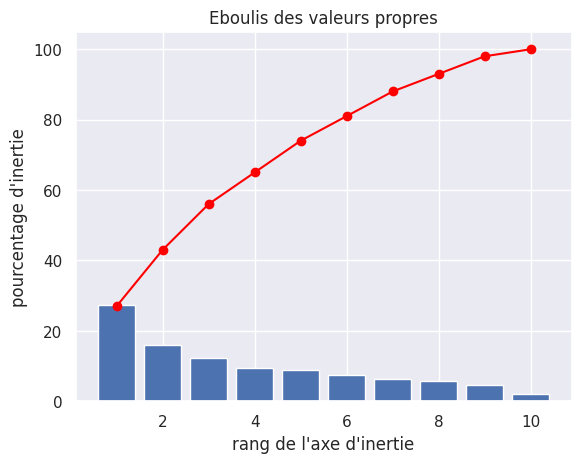

In [ ]:
# Graphique : Eboulis des valeurs propres
plt.bar(x_list, scree)
plt.plot(x_list, scree_cum,c="red",marker='o')
plt.xlabel("rang de l'axe d'inertie")
plt.ylabel("pourcentage d'inertie")
plt.title("Eboulis des valeurs propres")
#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Eboulis des valeurs propres.png", dpi=300, bbox_inches="tight")
plt.show(block=False)

# On a presque 65% de la variance  comprise dans les 4 premières composantes --> Partir sur 4 dimensions

> Ajouter une citation



In [ ]:
#Components
pcs = pca.components_
pcs

array([[ 0.34894333,  0.05145198, -0.07336077, -0.34180961, -0.30731871,
        -0.11317896,  0.47922767, -0.10896526,  0.50360429,  0.38855052],
       [-0.33951446, -0.59007739,  0.60667849,  0.07735047, -0.13554075,
        -0.26524956,  0.05642646, -0.14449923,  0.03989024,  0.21934652],
       [ 0.29815515, -0.28735741,  0.24312263,  0.21126709, -0.14403437,
         0.61493524,  0.34062392,  0.39729975, -0.01049851, -0.22784559],
       [-0.09810443, -0.00989198, -0.03960089, -0.17670007, -0.05761887,
        -0.45278523, -0.01343881,  0.86490316,  0.02216181, -0.02056448],
       [-0.21339586, -0.05816614,  0.0324821 , -0.20785993,  0.78988134,
         0.28617291,  0.13789024,  0.14229694,  0.18977951,  0.35458737],
       [-0.09996348,  0.11817955, -0.20069908,  0.85780116,  0.06115745,
        -0.15855716,  0.17272064,  0.07724448,  0.29917368,  0.21390025],
       [ 0.51830573, -0.42321509, -0.07493351,  0.04691525,  0.40080091,
        -0.33944243, -0.13348931, -0.10969702

In [ ]:
#Version Pandas
pcs = pd.DataFrame(pcs)
pcs

,0,1,2,3,4,5,6,7,8,9
0,0.348943,0.051452,-0.073361,-0.341810,-0.307319,-0.113179,0.479228,-0.108965,0.503604,0.388551
1,-0.339514,-0.590077,0.606678,0.077350,-0.135541,-0.265250,0.056426,-0.144499,0.039890,0.219347
2,0.298155,-0.287357,0.243123,0.211267,-0.144034,0.614935,0.340624,0.397300,-0.010499,-0.227846
3,-0.098104,-0.009892,-0.039601,-0.176700,-0.057619,-0.452785,-0.013439,0.864903,0.022162,-0.020564
4,-0.213396,-0.058166,0.032482,-0.207860,0.789881,0.286173,0.137890,0.142297,0.189780,0.354587
5,-0.099963,0.118180,-0.200699,0.857801,0.061157,-0.158557,0.172721,0.077244,0.299174,0.213900
6,0.518306,-0.423215,-0.074934,0.046915,0.400801,-0.339442,-0.133489,-0.109697,0.283592,-0.397860
7,0.040702,0.595557,0.669872,0.022798,0.129254,-0.095502,0.023249,-0.008572,0.284813,-0.294699
8,0.552484,0.078637,0.257631,0.131006,0.029822,0.009271,-0.450295,0.121657,-0.233756,0.576071
9,-0.182703,-0.095691,-0.061885,-0.049136,-0.239223,0.319704,-0.617236,0.090661,0.634417,-0.009812


In [ ]:
pcs.columns = cols
pcs.index = [f"F{i}" for i in x_list]
pcs.round(2)

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles
F1,0.35,0.05,-0.07,-0.34,-0.31,-0.11,0.48,-0.11,0.50,0.39
F2,-0.34,-0.59,0.61,0.08,-0.14,-0.27,0.06,-0.14,0.04,0.22
F3,0.30,-0.29,0.24,0.21,-0.14,0.61,0.34,0.40,-0.01,-0.23
F4,-0.10,-0.01,-0.04,-0.18,-0.06,-0.45,-0.01,0.86,0.02,-0.02
F5,-0.21,-0.06,0.03,-0.21,0.79,0.29,0.14,0.14,0.19,0.35
F6,-0.10,0.12,-0.20,0.86,0.06,-0.16,0.17,0.08,0.30,0.21
F7,0.52,-0.42,-0.07,0.05,0.40,-0.34,-0.13,-0.11,0.28,-0.40
F8,0.04,0.60,0.67,0.02,0.13,-0.10,0.02,-0.01,0.28,-0.29
F9,0.55,0.08,0.26,0.13,0.03,0.01,-0.45,0.12,-0.23,0.58
F10,-0.18,-0.10,-0.06,-0.05,-0.24,0.32,-0.62,0.09,0.63,-0.01


In [ ]:
pcs.T

,F1,F2,F3,F4,F5,F6,F7,F8,F9,F10
Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),0.348943,-0.339514,0.298155,-0.098104,-0.213396,-0.099963,0.518306,0.040702,0.552484,-0.182703
Quantité Aliments_disponible Poules(Milliers tonnes),0.051452,-0.590077,-0.287357,-0.009892,-0.058166,0.118180,-0.423215,0.595557,0.078637,-0.095691
Export_Utile(Milliers tonnes),-0.073361,0.606678,0.243123,-0.039601,0.032482,-0.200699,-0.074934,0.669872,0.257631,-0.061885
Taux de croissance_population [%],-0.341810,0.077350,0.211267,-0.176700,-0.207860,0.857801,0.046915,0.022798,0.131006,-0.049136
Emploi dans la production_vegetale_animale (1000No),-0.307319,-0.135541,-0.144034,-0.057619,0.789881,0.061157,0.400801,0.129254,0.029822,-0.239223
Distance_Economique Pays_France(Km),-0.113179,-0.265250,0.614935,-0.452785,0.286173,-0.158557,-0.339442,-0.095502,0.009271,0.319704
Indice Stabilite Politique,0.479228,0.056426,0.340624,-0.013439,0.137890,0.172721,-0.133489,0.023249,-0.450295,-0.617236
Croissance du PIB % annuel,-0.108965,-0.144499,0.397300,0.864903,0.142297,0.077244,-0.109697,-0.008572,0.121657,0.090661
"Qualité Reglementaire [-2,5..+2,5]",0.503604,0.039890,-0.010499,0.022162,0.189780,0.299174,0.283592,0.284813,-0.233756,0.634417
[%]surfaces agricoles biologiques/total des terres agricoles,0.388551,0.219347,-0.227846,-0.020564,0.354587,0.213900,-0.397860,-0.294699,0.576071,-0.009812


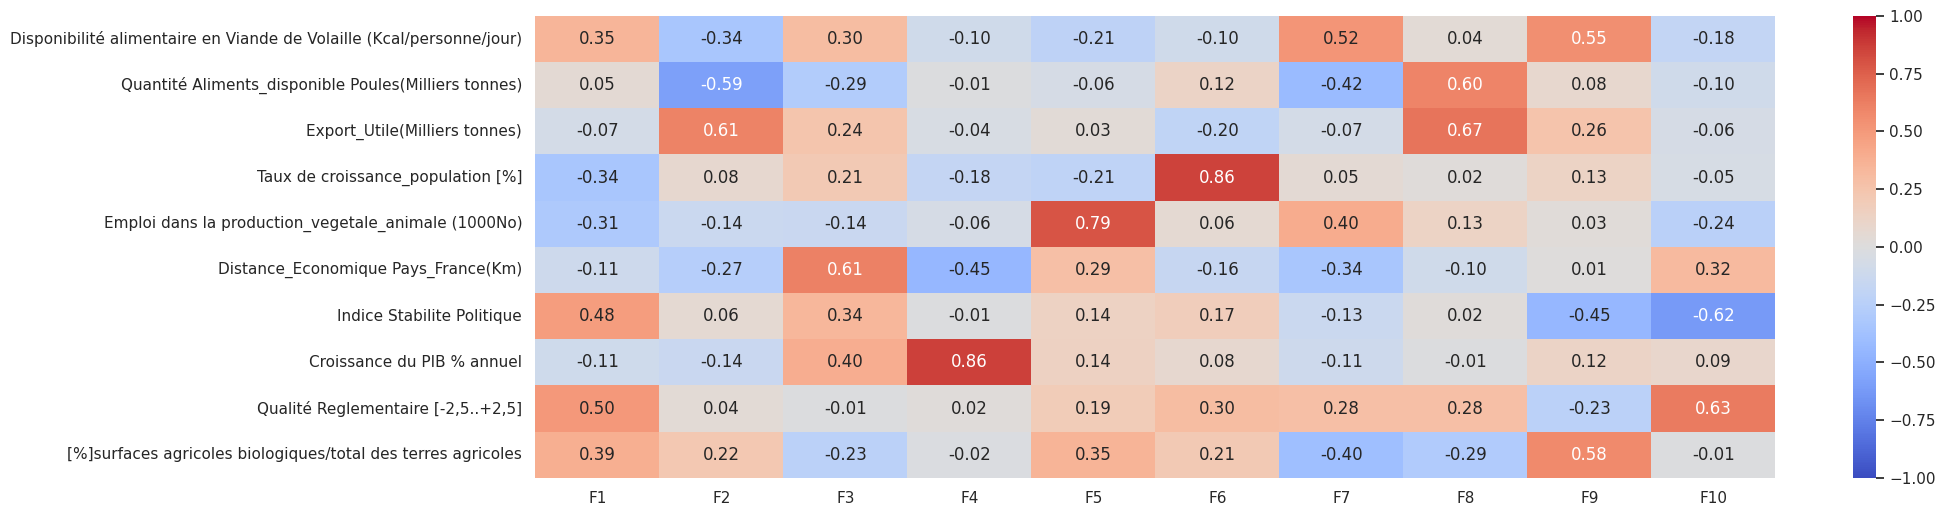

In [ ]:
#Heatmap pour les différents dimensions

fig, ax = plt.subplots(figsize=(20, 6))
sns.heatmap(pcs.T, vmin=-1, vmax=1, annot=True, cmap="coolwarm", fmt="0.2f")
#Génération de png
fig.savefig("heatmap_Composantes_principale.png", dpi=300, bbox_inches="tight")  # image HD
plt.show()

In [ ]:
F1 = pca.components_[0]
print(F1)

[ 0.34894333  0.05145198 -0.07336077 -0.34180961 -0.30731871 -0.11317896
  0.47922767 -0.10896526  0.50360429  0.38855052]


In [ ]:
#Fonction pour le cercle de corrélation

def correlation_graph(pca,
                      x_y,
                      features) :
    """Affiche le graphe des correlations

    Positional arguments :
    -----------------------------------
    pca : sklearn.decomposition.PCA : notre objet PCA qui a été fit
    x_y : list ou tuple : le couple x,y des plans à afficher, exemple [0,1] pour F1, F2
    features : list ou tuple : la liste des features (ie des dimensions) à représenter
    """

    # Extrait x et y
    x,y=x_y

    # Taille de l'image (en inches)
    fig, ax = plt.subplots(figsize=(10, 9))

    # Pour chaque composante :
    for i in range(0, pca.components_.shape[1]):

        # Les flèches
        ax.arrow(0,0,
                pca.components_[x, i],
                pca.components_[y, i],
                head_width=0.07,
                head_length=0.07,
                width=0.02, )

        # Les labels
        plt.text(pca.components_[x, i] + 0.01,
                pca.components_[y, i] + 0.01,
                features[i])

    # Affichage des lignes horizontales et verticales
    plt.plot([-1, 1], [0, 0], color='grey', ls='--')
    plt.plot([0, 0], [-1, 1], color='grey', ls='--')

    # Nom des axes, avec le pourcentage d'inertie expliqué
    plt.xlabel('F{} ({}%)'.format(x+1, round(100*pca.explained_variance_ratio_[x],1)))
    plt.ylabel('F{} ({}%)'.format(y+1, round(100*pca.explained_variance_ratio_[y],1)))

    plt.title("Cercle des corrélations (F{} et F{})".format(x+1, y+1))

    # Le cercle
    an = np.linspace(0, 2 * np.pi, 100)
    plt.plot(np.cos(an), np.sin(an))  # Add a unit circle for scale

    # Axes et display
    plt.axis('equal')
    #Géneration de png
    plt.savefig("/content/drive/MyDrive/Colab Notebooks/cercle_correlationF3_F4.png", dpi=300, bbox_inches="tight")
    plt.show(block=False)



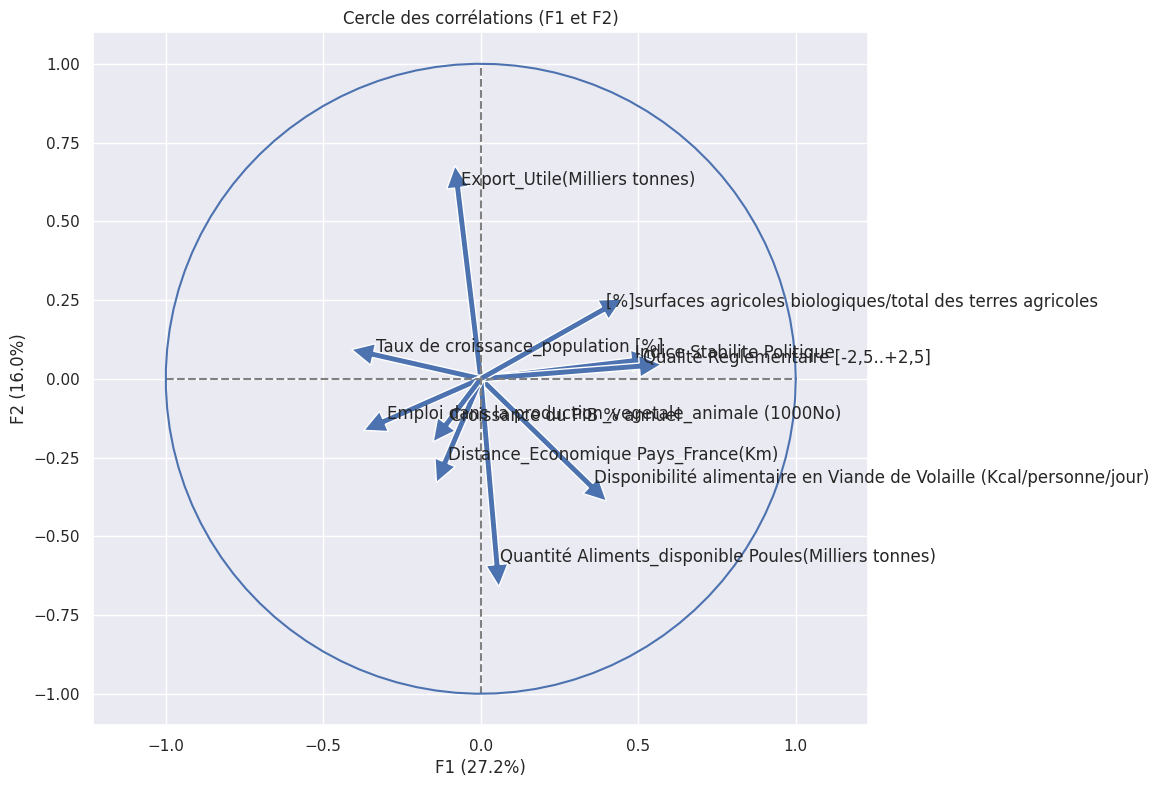

In [ ]:
#F1 et F2
correlation_graph(pca, (0,1), cols)

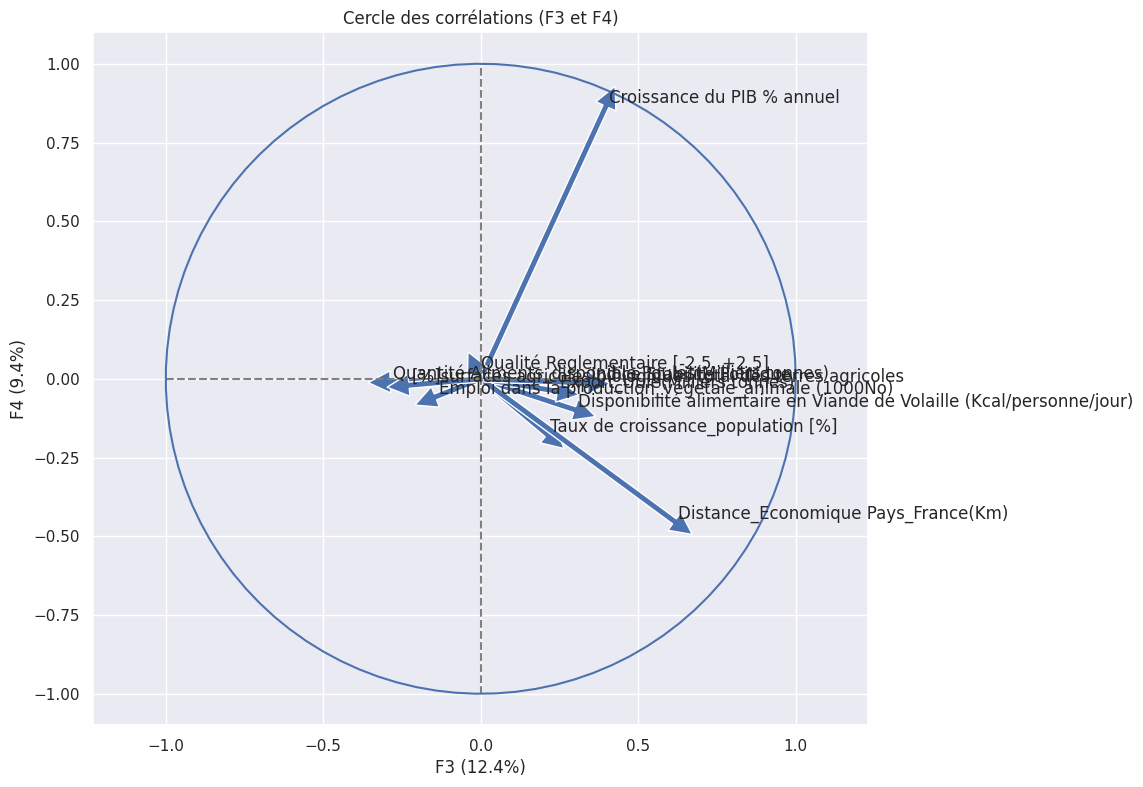

In [ ]:
#F3 et F4
correlation_graph(pca, (2,3), cols)

In [ ]:
#Projection des dimensions
#Calcul des coordonnées de nos individus dans le nouvel espace :
#Calcul des scores factoriles
X_proj = pca.transform(X_scaled)
X_proj[:5]
scores= X_proj

In [ ]:
#Préparation de la projection des pays

df_analyse.head()

,Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour),Quantité Aliments_disponible Poules(Milliers tonnes),Export_Utile(Milliers tonnes),Taux de croissance_population [%],Emploi dans la production_vegetale_animale (1000No),Distance_Economique Pays_France(Km),Indice Stabilite Politique,Croissance du PIB % annuel,"Qualité Reglementaire [-2,5..+2,5]",[%]surfaces agricoles biologiques/total des terres agricoles,cluster
Zone,,,,,,,,,,,
Afghanistan,5.0,254.0,26.0,78.88,1185.84,5489.888,-2.48,2.27,-1.27,0.00,1
Albania,85.0,438.0,38.0,-7.88,421.64,1461.321,0.18,3.96,0.17,0.06,1
Algeria,22.0,4858.0,2.0,36.04,0.00,1158.292,-0.58,3.30,-0.95,0.01,1
Angola,35.0,5873.0,277.0,87.92,5998.46,6363.600,-0.34,4.42,-0.76,0.00,1
Argentina,182.0,16332.0,-199.0,20.32,68.22,10921.860,-0.13,-1.72,-0.48,3.43,4


In [ ]:
#ACP avec 4 dimensions (2 plans factoriels)

from sklearn.decomposition import PCA

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled)

In [ ]:
df_pca = pd.DataFrame(
    X_pca,
    columns=['F1', 'F2','F3','F4']
)
df_analyse.reset_index()
df.columns



Index(['pays', 'cluster'], dtype='object')

In [ ]:
df_analyse.columns


Index(['Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour)',
       'Quantité Aliments_disponible Poules(Milliers tonnes)',
       'Export_Utile(Milliers tonnes)', 'Taux de croissance_population [%]',
       'Emploi dans la production_vegetale_animale (1000No)',
       'Distance_Economique Pays_France(Km)', 'Indice Stabilite Politique',
       'Croissance du PIB % annuel', 'Qualité Reglementaire [-2,5..+2,5]',
       '[%]surfaces agricoles biologiques/total des terres agricoles',
       'cluster'],
      dtype='object')

In [ ]:
df_reset = df_analyse.reset_index()
df_reset.head()
df_reset.columns

Index(['Zone',
       'Disponibilité alimentaire en Viande de Volaille (Kcal/personne/jour)',
       'Quantité Aliments_disponible Poules(Milliers tonnes)',
       'Export_Utile(Milliers tonnes)', 'Taux de croissance_population [%]',
       'Emploi dans la production_vegetale_animale (1000No)',
       'Distance_Economique Pays_France(Km)', 'Indice Stabilite Politique',
       'Croissance du PIB % annuel', 'Qualité Reglementaire [-2,5..+2,5]',
       '[%]surfaces agricoles biologiques/total des terres agricoles',
       'cluster'],
      dtype='object')

In [ ]:
df_pca['cluster'] = df_reset['cluster'].values
df_pca['Zone'] = df_reset['Zone'].values

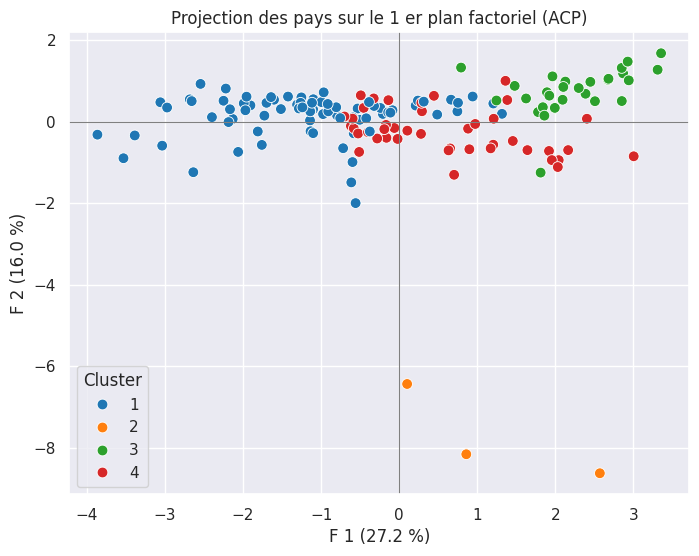

In [ ]:
#Projection des pays sur F1 et F2

import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x='F1',
    y='F2',
    hue='cluster',
    palette='tab10',
    s=60
)

plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)

plt.title("Projection des pays sur le 1 er plan factoriel (ACP)")
plt.xlabel(f"F 1 ({pca.explained_variance_ratio_[0]*100:.1f} %)")
plt.ylabel(f"F 2 ({pca.explained_variance_ratio_[1]*100:.1f} %)")

plt.legend(title="Cluster")

 #Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Projection des pays dans le plan factoriel (ACP).png", dpi=300, bbox_inches="tight")
plt.show()


la projection est étalée --> bonne présentation.
F1: Efficacité institutionnelle (porte 27,2% de l'information).
F2: Besoin de l'export en matière de viande de volialle(porte 16% de l'information).
Cluster 1 : 87% des  pays sont portés par la partie négative de F1(des pays qui ont des institutions non stables : des pays non stable politiquement) et 13%(10 pays par rapport à 78 pays) présentent des institutions efficaces. La plus part des pays de ce cluster (52 pays, 80% du cluster) ont besoin de l'export en matière de viande de volaille.
Cluster 2 : Les géants mondiaux de la filière avicole : Chine, Brézil et USA.
Cluster 3 : 99 % du cluster ont des institutions efficace (stabilité politique , % surface bio) et ont besoin de l'export en matière de viande de volaille.
Cluster 4 : 58% (25 pays par rapport à 43) des pays ont des institutions efficaces et 41% du cluster sont des pays à des institutions non stable. 33% du cluster ont besoin de l'export en matière de viande de volaille et 67% ont une autosuffisance en viande de volaille.



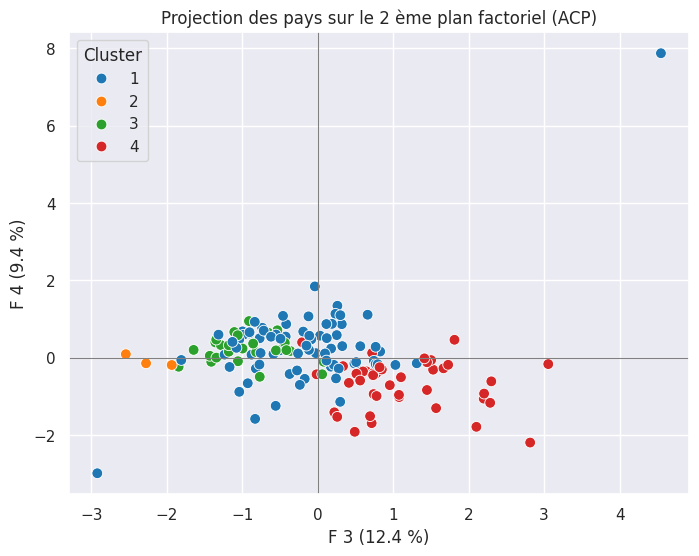

In [ ]:
#Projection des pays sur F3 et F4

plt.figure(figsize=(8,6))

sns.scatterplot(
    data=df_pca,
    x='F3',
    y='F4',
    hue='cluster',
    palette='tab10',
    s=60
)

plt.axhline(0, color='grey', linewidth=0.8)
plt.axvline(0, color='grey', linewidth=0.8)

plt.title("Projection des pays sur le 2 ème plan factoriel (ACP)")
plt.xlabel(f"F 3 ({pca.explained_variance_ratio_[2]*100:.1f} %)")
plt.ylabel(f"F 4 ({pca.explained_variance_ratio_[3]*100:.1f} %)")

plt.legend(title="Cluster")

 #Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Projection des pays dans le 2 eme plan factoriel (ACP).png", dpi=300, bbox_inches="tight")
plt.show()


F3 représente un axe complémentaire pour le 1 er plan Factoriel, il porte 12,4% de l'information par rapport à F4 qui porte 9,4%

F3: présente la distance économique entre la France et les autres pays : on va préviligier les pays ayant une distance économique faible ou négatif car ils présentent des pistes d'investissement plus simples et plus abordables par rapport aux autres pays ayant une grande distance.
Les pays économiquement proches sont plus rapides et moins risqués à adresser, car ils nécessitent moins d’adaptations et génèrent moins de frictions opérationnelles.

En appliquant le critère de Kaiser, on a tendance à ne pas considérer comme importants les axes dont l’inertie associée est inférieure à (100/p)%
 , car ils représentent moins de variabilité qu’une seule variable initiale. La valeur de (100/p)%
 est celle obtenue quand toutes les variables sont indépendantes deux à deux.
 Pour notre cas, p = 10 (nombre de variables initiales), (100/p)% = 10% --> Ne pas considérer l'axe F4 comme important(axe porté surtout par la variable croissance annuel du PIB) , de plus, nous avons bien notre boxplot avec les 4 clusters en fonction de la varibale croissance annuel du PIB.



En analysant bien les 2 plans factoriels, on trouve bien que le cluster 3 (28 pays : 26 pays de l'Europe + Uruguay+Sao Tome and Principe) répond bien à nos exigences: Des pays ayant une efficacité instututionnelle + des pays ont besoins de l'export en matière de viande de volaille + Une distance économique faible ou négatif avec la France (La France fait partie de ce cluster).

In [ ]:
#Filtrer le cluster numéro 3 et afficher ses pays corréspondant sur le 1 er plan factoriel


cluster_id = 3  # cluster à projeter

df_cluster = df_pca[df_pca['cluster'] == cluster_id]

df_cluster

,F1,F2,F3,F4,cluster,Zone
7,3.354339,1.674617,-1.844328,-0.235415,3,Austria
13,1.625133,0.565581,-1.357222,0.393475,3,Belgium
31,1.479242,0.874230,-0.911811,0.946556,3,Croatia
34,2.867998,1.181310,-1.039636,0.248598,3,Czechia
36,2.851382,0.502693,-0.535507,0.708083,3,Denmark
42,3.310123,1.270786,-1.411541,-0.107391,3,Estonia
46,2.674131,1.025040,-1.058363,-0.092604,3,Finland
47,1.993226,0.334729,-1.285248,0.326156,3,France
50,2.386841,0.681537,-1.431479,0.048119,3,Germany
52,1.963505,1.107394,-1.345729,0.466383,3,Greece


In [ ]:
liste = df_cluster['Zone']
print(liste)

7                                                Austria
13                                               Belgium
31                                               Croatia
34                                               Czechia
36                                               Denmark
42                                               Estonia
46                                               Finland
47                                                France
50                                               Germany
52                                                Greece
59                                               Hungary
60                                               Iceland
64                                               Ireland
66                                                 Italy
75                                                Latvia
79                                             Lithuania
80                                            Luxembourg
102                            

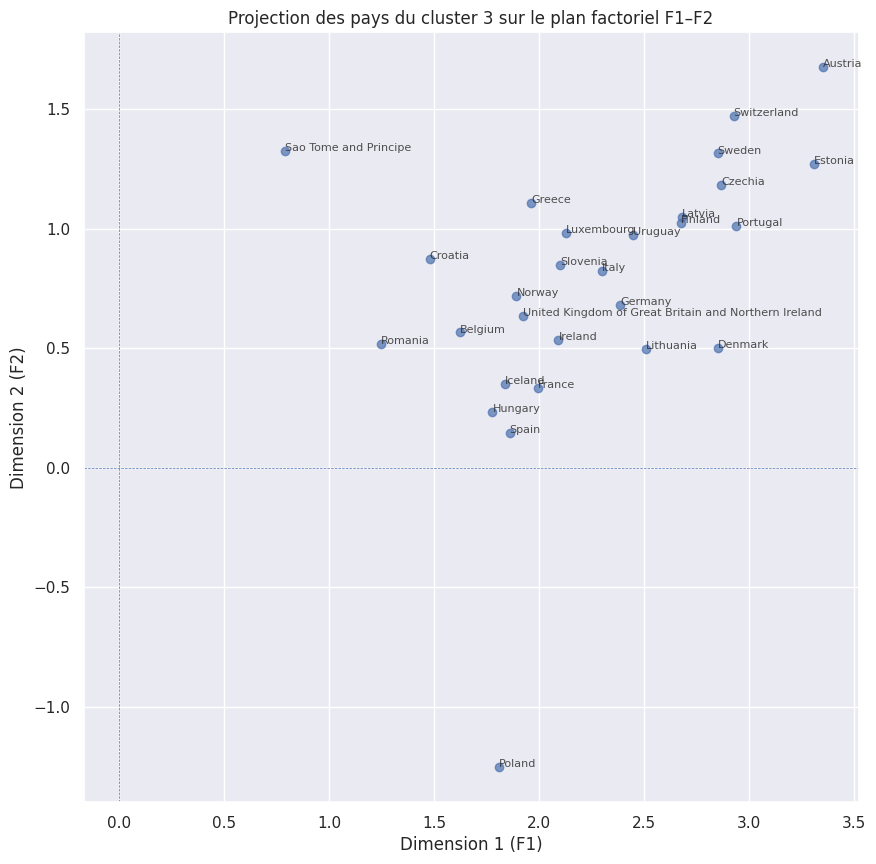

In [ ]:


plt.figure(figsize=(10, 10))

plt.scatter(
    df_cluster['F1'],
    df_cluster['F2'],
    alpha=0.7
)

# Ajouter les noms des pays
for _, row in df_cluster.iterrows():
    plt.text(
        row['F1'],
        row['F2'],
        row['Zone'],
        fontsize=8,
        alpha=0.8
    )

plt.axhline(0, linestyle='--', linewidth=0.5)
plt.axvline(0, linestyle='--', linewidth=0.5)

plt.xlabel('Dimension 1 (F1)')
plt.ylabel('Dimension 2 (F2)')
plt.title(f'Projection des pays du cluster {cluster_id} sur le plan factoriel F1–F2')
plt.grid(True)
#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Projection des pays du cluster 3 sur le plan factoriel F1–F2.png", dpi=300, bbox_inches="tight")
plt.show()


Proioriser les pays du cluster 3

In [ ]:
#Projeter le cluster 3 sur un plan 3D F1,F2 et F3

df_cluster3 = df_cluster
df_cluster3.head()




,F1,F2,F3,F4,cluster,Zone
7,3.354339,1.674617,-1.844328,-0.235415,3,Austria
13,1.625133,0.565581,-1.357222,0.393475,3,Belgium
31,1.479242,0.874230,-0.911811,0.946556,3,Croatia
34,2.867998,1.181310,-1.039636,0.248598,3,Czechia
36,2.851382,0.502693,-0.535507,0.708083,3,Denmark


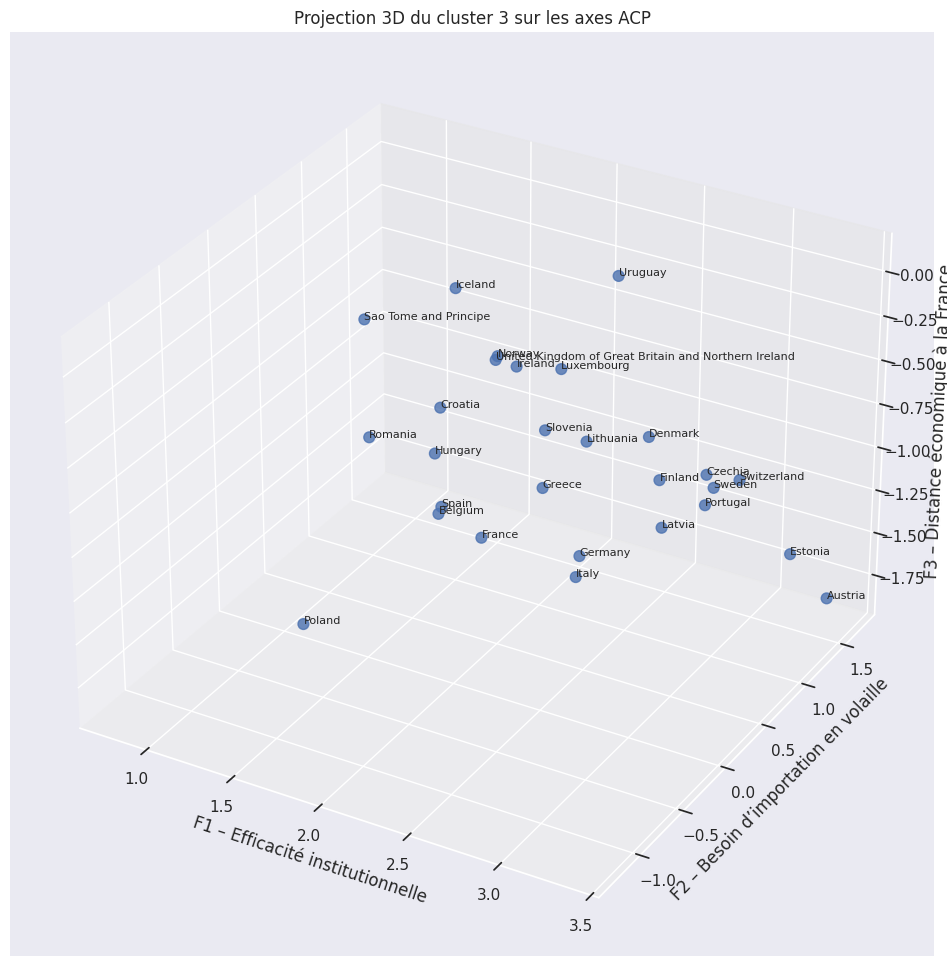

In [ ]:

from mpl_toolkits.mplot3d import Axes3D

fig = plt.figure(figsize=(12, 12))
ax = fig.add_subplot(111, projection='3d')

ax.scatter(
    df_cluster3["F1"],
    df_cluster3["F2"],
    df_cluster3["F3"],
    s=60,
    alpha=0.8
)

ax.set_xlabel("F1 – Efficacité institutionnelle")
ax.set_ylabel("F2 – Besoin d’importation en volaille")
ax.set_zlabel("F3 – Distance économique à la France")

ax.set_title("Projection 3D du cluster 3 sur les axes ACP")

#Affichage des noms des pays
for i, country in enumerate(df_cluster3["Zone"]):
    ax.text(
        df_cluster3["F1"].iloc[i],
        df_cluster3["F2"].iloc[i],
        df_cluster3["F3"].iloc[i],
        country,
        fontsize=8
    )

#Géneration de png
plt.savefig("/content/drive/MyDrive/Colab Notebooks/Projection_cluster 3 en 3D.png", dpi=300, bbox_inches="tight")

plt.show()
